In [1]:
# Instalaçãp da biblioteca Ultralytics
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 847.2 kB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using

In [2]:
# Desativando os avisos no notebook para manter células de saída limpas
import warnings
warnings.filterwarnings('ignore')

# Importação das bibliotecas necessárias
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import yaml
from PIL import Image
from ultralytics import YOLO
from IPython.display import Video

In [3]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Programa k/Organizacao do Trafego')
HOME = os.getcwd()

Mounted at /content/drive


In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key="CxkSFwEwGeDbi7yYJtKo")
project = rf.workspace("visao-computacional-n1het").project("deteccao-de-automoveis")
version = project.version(1)
dataset = version.download("yolov8-obb")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
# Configurando a aparência visual dos gráficos do Seaborn
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')

# Carregando um modelo YOLOv8n pré-treinado do Ultralytics
model = YOLO('yolov8n.pt')


image 1/1 /content/drive/MyDrive/Programa k/Organizacao do Trafego/image_sample.jpg: 640x640 1 car, 7.9ms
Speed: 7.4ms preprocess, 7.9ms inference, 726.1ms postprocess per image at shape (1, 3, 640, 640)


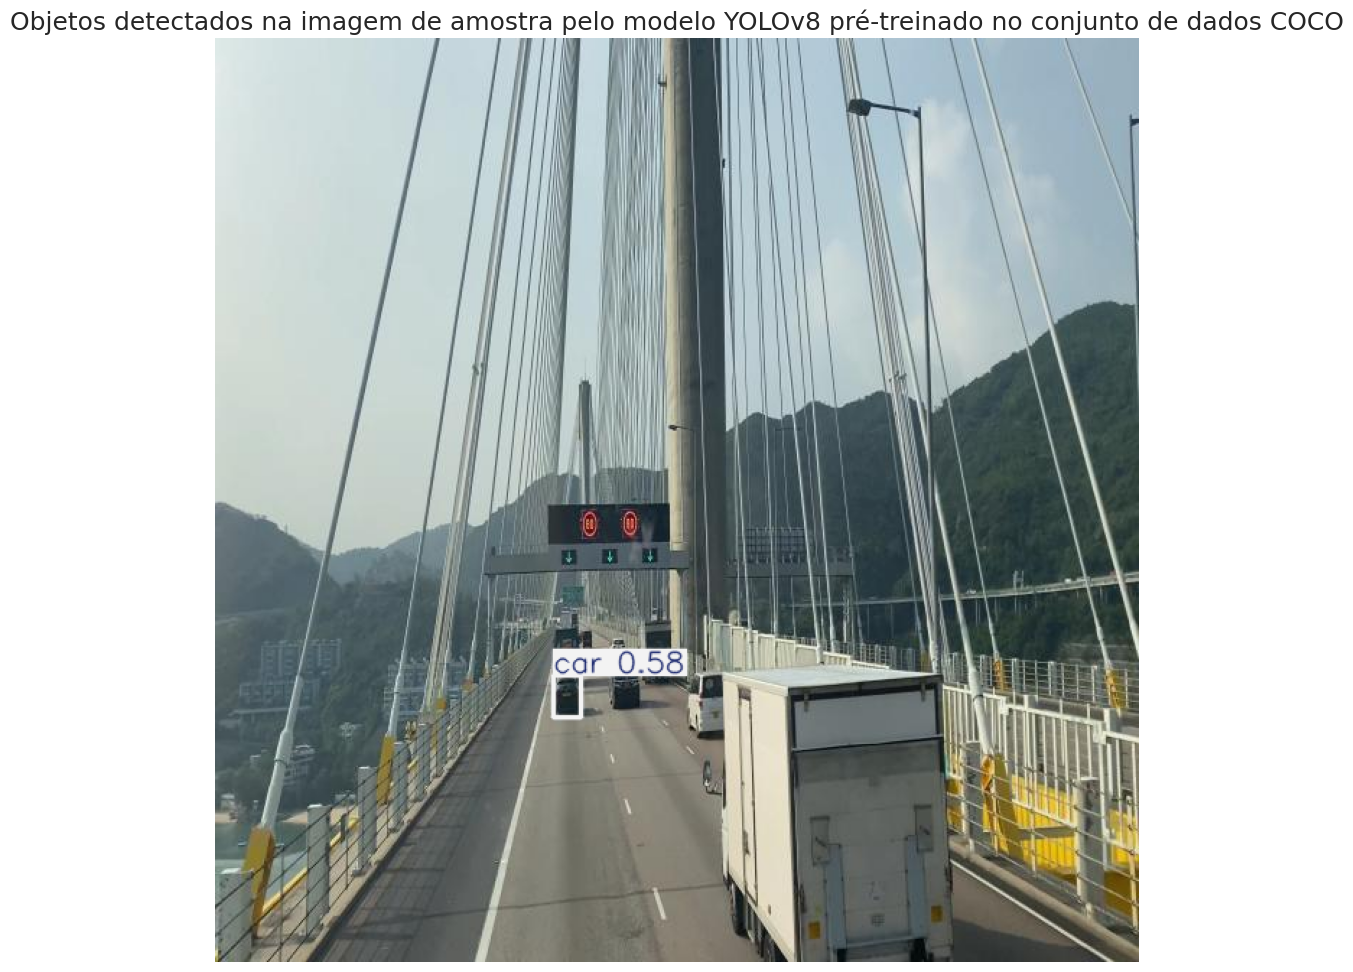

In [6]:
image_path = 'image_sample.jpg'

# Realizando inferência nas imagens fornecidas
results = model.predict(source=image_path,
                        imgsz=640,  # Redimensionando a imagem para 640x640 (o tamanho das imagens nas quais o modelo foi treinado)
                        conf=0.5)   # Limite de confiança: 50% (somente detecções acima de 50% de confiança serão consideradas)

# Anota e converta a imagem em array numpy
sample_image = results[0].plot(line_width=2)

# Converta a cor da imagem de BGR para RGB para representação correta de cores no matplotlib
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Exibir imagem anotada
plt.figure(figsize=(18,12))
plt.imshow(sample_image)
plt.title('Objetos detectados na imagem de amostra pelo modelo YOLOv8 pré-treinado no conjunto de dados COCO', fontsize=18)
plt.axis('off')
plt.show()

In [ ]:
# Treine o modelo em nosso conjunto de dados personalizado
results = model.train(
    data=f'{dataset.location}/data.yaml',     # Caminho para o arquivo de configuração do conjunto de dados
    epochs=50,                                           # Número de épocas para treinar
    imgsz=640,                                            # Tamanho das imagens de entrada como número inteiro
    device=0,                                             # Dispositivo para execução, ou seja, dispositivo cuda = 0
    patience=50,                                          # Épocas para esperar por nenhuma melhoria observável para a interrupção antecipada do treinamentog
    batch=16,                                             # Número de imagens por lote
    optimizer='auto',                                     # Otimizador a ser usado, escolhas=[SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto]
    lr0=0.0001,                                           # Taxa de aprendizagem inicial
    lrf=0.1,                                              # Taxa final de aprendizagem (lr0 * lrf)
    dropout=0.1,                                          # Use regularização de abandono
    seed=0,                                               # Semente aleatória para reprodutibilidade
    name='detect_vehicle'
)

Ultralytics YOLOv8.2.80 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Programa k/Organizacao do Trafego/Detecção-de-Automovéis-1/data.yaml, epochs=50, time=None, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=detect_vehicle, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.1, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sav

train: Scanning /content/drive/MyDrive/Programa k/Organizacao do Trafego/Detecção-de-Automovéis-1/train/labels.cache... 1064 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1064/1064 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/Programa k/Organizacao do Trafego/Detecção-de-Automovéis-1/valid/labels.cache... 94 images, 0 backgrounds, 0 corrupt: 100%|██████████| 94/94 [00:00<?, ?it/s]


Plotting labels to runs/detect/detect_vehicle/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/detect_vehicle
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50      2.21G     0.9237     0.4589     0.9293         52        640: 100%|██████████| 67/67 [00:27<00:00,  2.43it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  1.67it/s]

                   all         94        884      0.933      0.923      0.976       0.74



50 epochs completed in 0.715 hours.
Optimizer stripped from runs/detect/detect_vehicle/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/detect_vehicle/weights/best.pt, 6.2MB

Validating runs/detect/detect_vehicle/weights/best.pt...
Ultralytics YOLOv8.2.80 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:03<00:00,  1.30s/it]


                   all         94        884      0.917      0.946      0.975       0.74
Speed: 0.3ms preprocess, 2.8ms inference, 0.0ms loss, 6.3ms postprocess per image
Results saved to runs/detect/detect_vehicle


In [7]:
# Define o caminho para o diretório
post_training_files_path = 'runs/detect/detect_vehicle'

# Lista os arquivos no diretório
files_in_directory = os.listdir(post_training_files_path)

# Exibi os arquivos
print(files_in_directory)

['weights', 'args.yaml', 'labels_correlogram.jpg', 'labels.jpg', 'train_batch1.jpg', 'train_batch0.jpg', 'train_batch2.jpg', 'train_batch2680.jpg', 'train_batch2682.jpg', 'train_batch2681.jpg', 'results.csv', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'PR_curve.png', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'F1_curve.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'P_curve.png', 'R_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png', 'events.out.tfevents.1724354683.4515000b017e.8208.0']


In [8]:
# Define uma função para traçar curvas de aprendizado para valores de perda
def plot_learning_curve(df, train_loss_col, val_loss_col, title):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df, x='epoch', y=train_loss_col, label='Train Loss', color='#141140', linestyle='-', linewidth=2)
    sns.lineplot(data=df, x='epoch', y=val_loss_col, label='Validation Loss', color='orangered', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

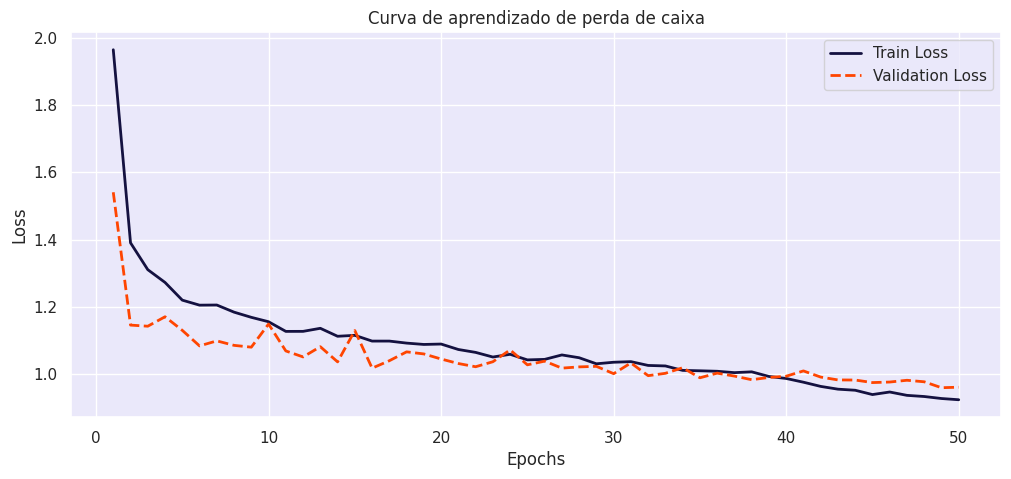

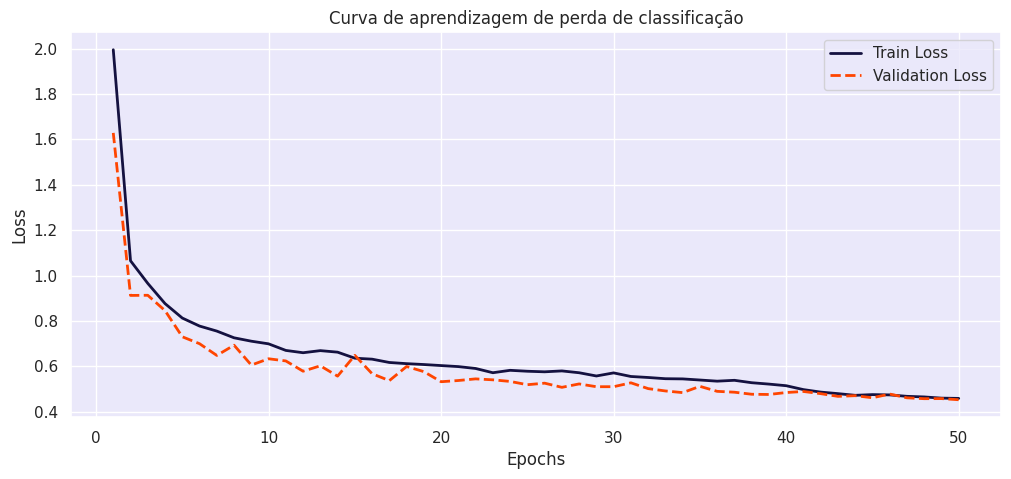

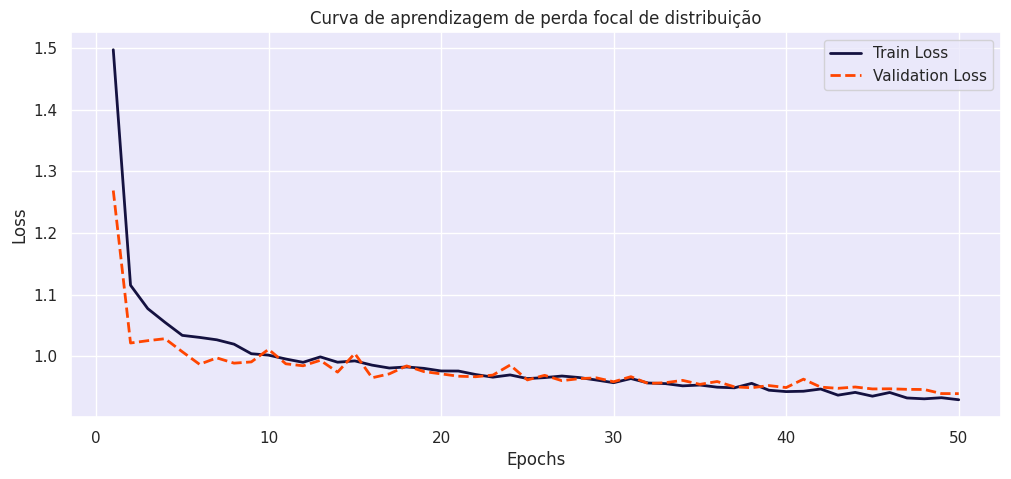

In [9]:
# Crie o caminho completo do arquivo para 'results.csv' usando o caminho do diretório e o nome do arquivo
results_csv_path = os.path.join(post_training_files_path, 'results.csv')

# Carregue o arquivo CSV do caminho construído em um DataFrame do pandas
df = pd.read_csv(results_csv_path)

# Remova qualquer espaço em branco inicial dos nomes das colunas
df.columns = df.columns.str.strip()

# lote as curvas de aprendizado para cada perda
plot_learning_curve(df, 'train/box_loss', 'val/box_loss', 'Curva de aprendizado de perda de caixa')
plot_learning_curve(df, 'train/cls_loss', 'val/cls_loss', 'Curva de aprendizagem de perda de classificação')
plot_learning_curve(df, 'train/dfl_loss', 'val/dfl_loss', 'Curva de aprendizagem de perda focal de distribuição')

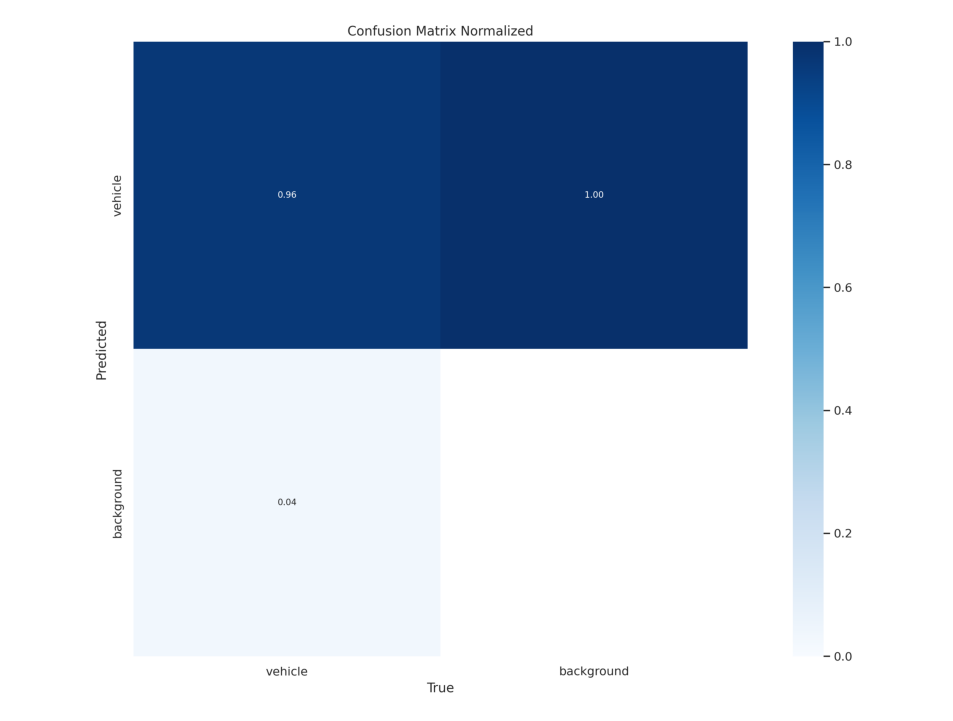

In [10]:
# Construa o caminho para a imagem da matriz de confusão normalizada
confusion_matrix_path = os.path.join(post_training_files_path, 'confusion_matrix_normalized.png')

# Leia a imagem usando cv
cm_img = cv2.imread(confusion_matrix_path)

# Converta a imagem do espaço de cores BGR para RGB para uma representação de cores precisa com matplotlib
cm_img = cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB)

# Exibir a imagem
plt.figure(figsize=(10, 10), dpi=120)
plt.imshow(cm_img)
plt.axis('off')
plt.show()

In [11]:
# Construa o caminho para o melhor arquivo de pesos do modelo usando os.path.join
best_model_path = os.path.join(post_training_files_path, 'weights/best.pt')

# Carregue os melhores pesos do modelo no modelo YOLO
best_model = YOLO(best_model_path)

# Valide o melhor modelo usando o conjunto de validação com parâmetros padrão
metrics = best_model.val(split='val')

Ultralytics YOLOv8.2.82 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 21.9MB/s]
val: Scanning /content/drive/MyDrive/Programa k/Organizacao do Trafego/Detecção-de-Automovéis-1/valid/labels.cache... 94 images, 0 backgrounds, 0 corrupt: 100%|██████████| 94/94 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:17<00:00,  2.93s/it]


                   all         94        884      0.916      0.946      0.975       0.74
Speed: 0.9ms preprocess, 8.2ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to runs/detect/val


In [12]:
# Converta o dicionário em um DataFrame do pandas e use as chaves como índice
metrics_df = pd.DataFrame.from_dict(metrics.results_dict, orient='index', columns=['Métrica Valor'])

# Exibir o DataFrame
metrics_df.round(3)

,Métrica Valor
metrics/precision(B),0.916
metrics/recall(B),0.946
metrics/mAP50(B),0.975
metrics/mAP50-95(B),0.740
fitness,0.763



image 1/1 /content/drive/MyDrive/Programa k/Organizacao do Trafego/image_sample.jpg: 640x640 4 vehicles, 18.7ms
Speed: 2.4ms preprocess, 18.7ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)


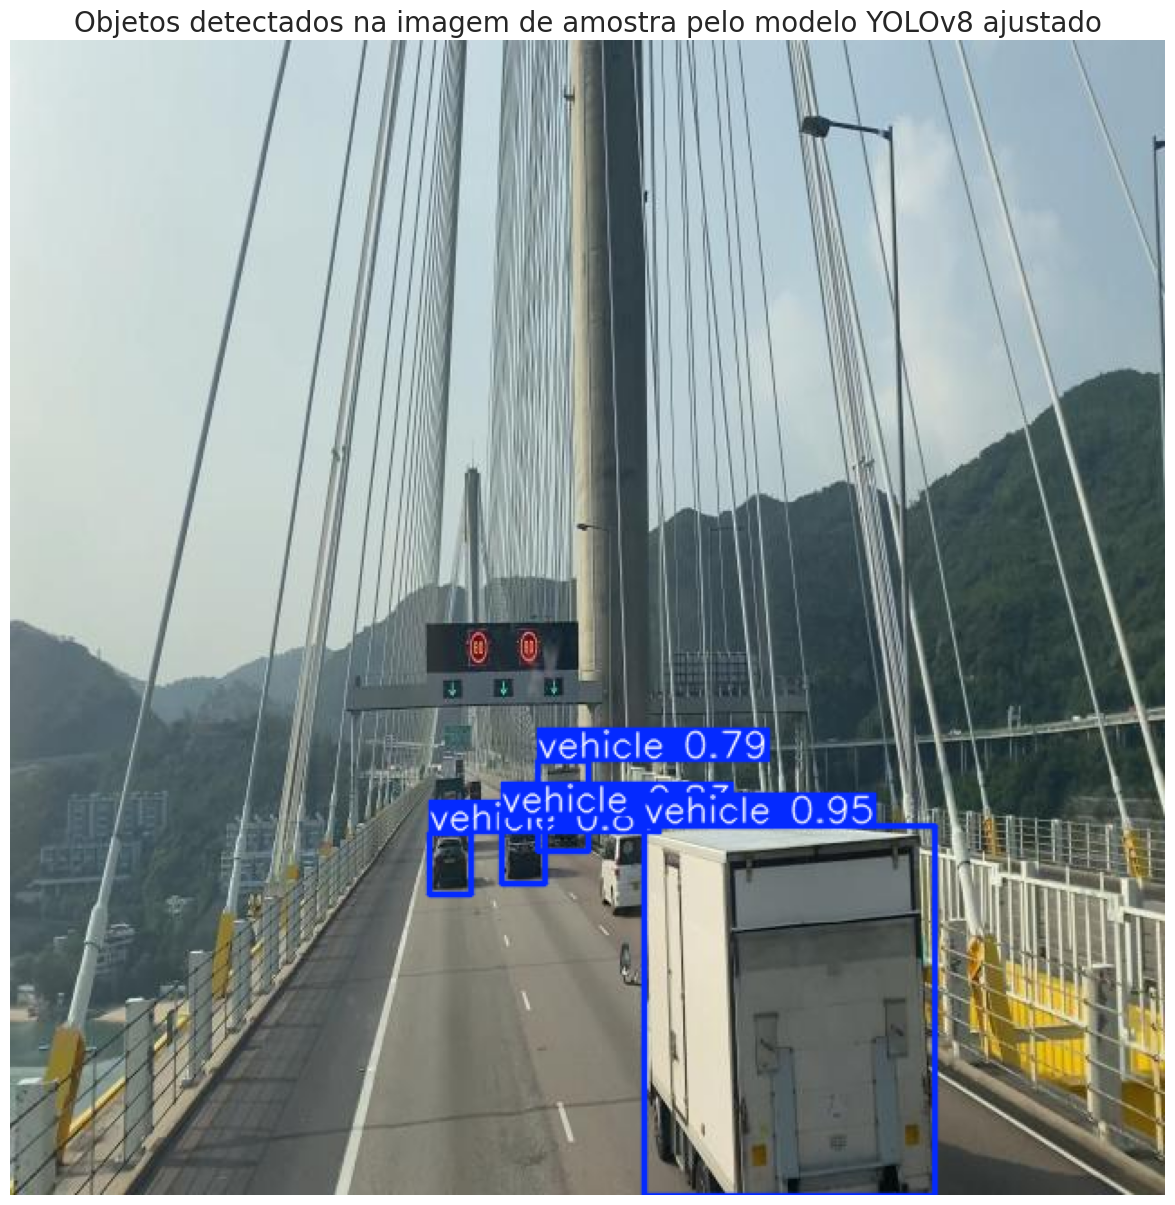

In [14]:
# Caminho para o arquivo de imagem
sample_image_path = 'image_sample.jpg'

# Execute inferência na imagem fornecida usando o melhor modelo
results = best_model.predict(source=sample_image_path, imgsz=640, conf=0.7)

# Anote e converta a imagem em array numpy
sample_image = results[0].plot(line_width=2)

# Converta a cor da imagem de BGR para RGB para representação correta de cores no matplotlib
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Exibir imagem anotada
plt.figure(figsize=(20,15))
plt.imshow(sample_image)
plt.title('Objetos detectados na imagem de amostra pelo modelo YOLOv8 ajustado', fontsize=20)
plt.axis('off')
plt.show()

Obs: as coordenadas dos vértices

In [19]:
# Defina o limite para considerar o tráfego como pesado
heavy_traffic_threshold = 10

# Nova resolução do vídeo
nova_largura = 1280
nova_altura = 720

# Fatores de escala
fator_escala_x = nova_largura / 384  # Para o eixo x
fator_escala_y = nova_altura / 640   # Para o eixo y

# Ajustar as coordenadas dos vértices para o primeiro quadrilátero
novos_vertices1 = np.array([(465, 350), (609, 350), (510, 630), (2, 630)], dtype=np.int32)

# Ajustar as coordenadas dos vértices para o segundo quadrilátero
novos_vertices2 = np.array([(678, 350), (815, 350), (1203, 630), (743, 630)], dtype=np.int32)

# Defina o intervalo vertical para o limite de fatia e pista
x1, x2 = 325, 635
lane_threshold = 609

# Defina as posições das anotações de texto na imagem
text_position_left_lane = (10, 50)
text_position_right_lane = (820, 50)
intensity_position_left_lane = (10, 100)
intensity_position_right_lane = (820, 100)

# Defina fonte, escala e cores para as anotaçõess
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_color = (255, 255, 255)    # White color for text
background_color = (0, 0, 255)  # Red background for text

# Abra o vídeo
cap = cv2.VideoCapture('cars4.mp4')

# Obtenha as dimensões reais do vídeo
video_width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
video_height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

# Definindo o codec e crie o objeto VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('densidade_trafego_do_video_teste.avi', fourcc, 20.0, (int(cap.get(3)), int(cap.get(4))))

# Leia até que o vídeo seja concluído
while cap.isOpened():
    # Capturar quadro a quadro
    ret, frame = cap.read()
    if ret:
        # Crie uma cópia do quadro original para modificar
        detection_frame = frame.copy()

        # Escureça as regiões fora do intervalo vertical especificado
        detection_frame[:x1, :] = 0  # Escureça de cima para x1
        detection_frame[x2:, :] = 0  # Escureça de x2 até a parte inferior do quadro

        # Execute inferência no quadro modificado
        results = best_model.predict(detection_frame, imgsz=640, conf=0.4)
        processed_frame = results[0].plot(line_width=1)

        # Restaure as partes superiores e inferiores originais da moldura
        processed_frame[:x1, :] = frame[:x1, :].copy()
        processed_frame[x2:, :] = frame[x2:, :].copy()

        # Desenhe os quadriláteros no quadro processado
        cv2.polylines(processed_frame, [novos_vertices1], isClosed=True, color=(0, 255, 0), thickness=2)
        cv2.polylines(processed_frame, [novos_vertices2], isClosed=True, color=(255, 0, 0), thickness=2)

        # Recuperar as caixas delimitadoras dos resultados
        bounding_boxes = results[0].boxes

        # Inicialize contadores para veículos em cada faixa
        vehicles_in_left_lane = 0
        vehicles_in_right_lane = 0

        # Percorra cada caixa delimitadora para contar veículos em cada faixa
        for box in bounding_boxes.xyxy:
            # Verifique se o veículo está na faixa da esquerda com base na coordenada x da caixa delimitadora
            if box[0] < lane_threshold:
                vehicles_in_left_lane += 1
            else:
                vehicles_in_right_lane += 1

        # Determine a intensidade do tráfego para a faixa da esquerda
        traffic_intensity_left = "Pesado" if vehicles_in_left_lane > heavy_traffic_threshold else "Leve"
        # Determine a intensidade do tráfego para a faixa da direita
        traffic_intensity_right = "Pesado" if vehicles_in_right_lane > heavy_traffic_threshold else "Leve"


        # Adicione um retângulo de fundo para a contagem de veículos na faixa esquerda
        cv2.rectangle(processed_frame, (text_position_left_lane[0]-10, text_position_left_lane[1] - 25),
                      (text_position_left_lane[0] + 460, text_position_left_lane[1] + 10), background_color, -1)

        # Adicione o texto de contagem de veículos no topo do retângulo da faixa da esquerda
        cv2.putText(processed_frame, f'Veículos na faixa da esquerda: {vehicles_in_left_lane}', text_position_left_lane,
                    font, font_scale, font_color, 2, cv2.LINE_AA)

        # Adicione um retângulo de fundo para a intensidade do tráfego na faixa da esquerda
        cv2.rectangle(processed_frame, (intensity_position_left_lane[0]-10, intensity_position_left_lane[1] - 25),
                      (intensity_position_left_lane[0] + 460, intensity_position_left_lane[1] + 10), background_color, -1)

        # Adicione o texto de intensidade de tráfego no topo do retângulo para a LAN esquerda
        cv2.putText(processed_frame, f'Intensidade de tráfego: {traffic_intensity_left}', intensity_position_left_lane,
                    font, font_scale, font_color, 2, cv2.LINE_AA)

        # Adicione um retângulo de fundo para o número de veículos na faixa da direita
        cv2.rectangle(processed_frame, (text_position_right_lane[0]-10, text_position_right_lane[1] - 25),
                      (text_position_right_lane[0] + 460, text_position_right_lane[1] + 10), background_color, -1)

        # Adicione o texto da contagem de veículos no topo do retângulo da faixa da direita
        cv2.putText(processed_frame, f'Veículos na faixa da direita: {vehicles_in_right_lane}', text_position_right_lane,
                    font, font_scale, font_color, 2, cv2.LINE_AA)

        # Adicione um retângulo de fundo para a intensidade de tráfego da faixa direita
        cv2.rectangle(processed_frame, (intensity_position_right_lane[0]-10, intensity_position_right_lane[1] - 25),
                      (intensity_position_right_lane[0] + 460, intensity_position_right_lane[1] + 10), background_color, -1)

        # Adicione o texto de intensidade de tráfego no topo do retângulo da faixa da direita
        cv2.putText(processed_frame, f'Intensidade de tráfego: {traffic_intensity_right}', intensity_position_right_lane,
                    font, font_scale, font_color, 2, cv2.LINE_AA)

        # Grave o quadro processado no vídeo de saída
        out.write(processed_frame)

        # Remova o comentário das três linhas a seguir se estiver executando este código em uma máquina local para visualizar os resultados do processamento em tempo real
        # cv2.imshow('Real-time Analysis', processed_frame)
        # if cv2.waitKey(1) & 0xFF == ord('q'):  # Pressione Q no teclado para sair do loop
        #     break
    else:
        break

# Libere os objetos de captura e gravação de vídeo
cap.release()
out.release()

# Feche todos os quadros
# cv2.destroyAllWindows()


0: 384x640 (no detections), 25.7ms
Speed: 1.6ms preprocess, 25.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 12.7ms
Speed: 1.6ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 14.9ms
Speed: 1.5ms preprocess, 14.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.6ms
Speed: 2.7ms preprocess, 9.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 12.2ms
Speed: 1.6ms preprocess, 12.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.6ms
Speed: 1.5ms preprocess, 11.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.0ms
Speed: 1.4ms preprocess, 11.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 15.0ms
Speed: 1.4ms preprocess, 15.0ms inf